In [1]:
import os
import pathlib
import sys

DNSCBOR_EVAL_DIR = pathlib.Path.cwd() / "04_cbor4dns_eval"
os.environ["DNSCBOR_EVAL_DIR"] = str(DNSCBOR_EVAL_DIR)
if str(DNSCBOR_EVAL_DIR) not in sys.path:
    sys.path.append(str(DNSCBOR_EVAL_DIR))

from utils import list_code

# Evaluating CBOR as DNS Message Format
## Method

We summarize our method in the figure below (Figure 9 in the paper).
We generate a DNS PCAP from names collected in the Tranco list, using MassDNS, and also include PCAPs from 3 IoT datasets.
For Section 4.3 “Potentials for Optimization by Sharing Common IP Prefixes and Name Suffixes”, we also include a CSV extracted from [SecSpider] and DNS JSONs from a [Web PKI Study by Tehrani et al.][Web PKI Study].
The PCAPs were used to analyse the compression provided by the application/dns+cbor format and our proposed improvements in Section 4.2 “The application/dns+cbor DNS Message Format” and Section 4.4 “Name Compression in Unpacked application/dns+cbor”.

[SecSpider]: https://secspider.net/
[Web PKI Study]: https://doi.org/10.23919/TMA62044.2024.10559089

In [2]:
%load_ext jupyter_tikz

preamble = r"""
\usepackage{adjustbox}
\usepackage{fontawesome5}
\usepackage[T1]{fontenc}
\usepackage{graphicx}
\usepackage{ifthen}
\usepackage[tt=false, type1=true]{libertine}
\usepackage[varqu]{zi4}
\usepackage[libertine]{newtxmath}
\usepackage{cleveref}
\usepackage{tikz}

\crefname{section}{Section}{Sections}
\crefname{figure}{Figure}{Figures}

\usetikzlibrary{
  arrows.meta,
  calc,
  colorbrewer,
  fadings,
  fit,
  positioning
}
\pgfdeclarelayer{bg}
\pgfsetlayers{bg,main}
""" \
fr"""\graphicspath{{{{{(DNSCBOR_EVAL_DIR / "plots").relative_to(pathlib.Path.cwd())}{os.sep}}}}}
"""

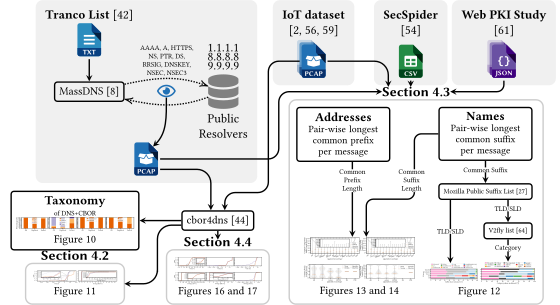

In [3]:
%%tikz -p "$preamble" -S 04_cbor4dns_eval/figs/dns-collect
\adjustbox{scale=1.4}{\input{04_cbor4dns_eval/figs/dns-collect.tex}}

## Dataset Collection

We provided the PCAP generated from the Tranco list, the SecSpider CSV and the Web PKI Study data [here][TBD].
For instructions how to collect your own Tranco list and how to get the IoT datasets, please have a look at [this notebook](./04_cbor4dns_eval/01_data_collection.ipynb).